# YOLO26 Vessel Detection Experiments with SAHI

**Variables tested:**
- Image size: 512, 640, 768, 1024
- Epochs: 50, 100, 150, 200
- Model size: nano, small, medium, large
- SAHI inference: Compare standard vs SAHI inference for each trained model

## 1. Setup and Configuration

In [2]:
# Install packages if needed (run once, then restart kernel)
import sys
!{sys.executable} -m pip install --user numpy==1.26.4 pandas ultralytics sahi matplotlib --quiet

In [3]:
from ultralytics import YOLO
import torch
import time
import gc
import json
from datetime import datetime
from pathlib import Path
import os

# Verify GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Training will be very slow.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA B200
GPU Memory: 191.5 GB


In [4]:
# Check SAHI installation
try:
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction, get_prediction
    SAHI_AVAILABLE = True
    print("SAHI installed and ready")
except ImportError:
    SAHI_AVAILABLE = False
    print("SAHI not installed. Run: pip install sahi")
    print(" SAHI evaluation will be skipped.")

SAHI installed and ready


In [5]:
data_yaml_path = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml"

# For SAHI evaluation - path to validation images
val_images_dir = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/images/val"

val_labels_dir = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/labels/val"

# Where to save progress (so we can resume if kernel crashes)
progress_file = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/experiment_progress.json"

# Verify paths exist
for path, name in [(data_yaml_path, "Data config"), (val_images_dir, "Val images"),
                   (val_labels_dir, "Val labels")]:
    if Path(path).exists():
        print(f"{name} found: {path}")
    else:
        print(f"{name} NOT found: {path}")

Data config found: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml
Val images found: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/images/val
Val labels found: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/labels/val


## 2. Helper Functions

In [6]:
def clear_memory():
    """Clear GPU and CPU memory between experiments."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print("   Memory cleared.")


def save_progress(results, filepath):
    """Save experiment progress to JSON file."""
    # Convert any non-serializable objects
    clean_results = []
    for r in results:
        clean_r = {}
        for k, v in r.items():
            if isinstance(v, (int, float, str, bool, type(None))):
                clean_r[k] = v
            else:
                clean_r[k] = str(v)
        clean_results.append(clean_r)
    
    with open(filepath, 'w') as f:
        json.dump(clean_results, f, indent=2)
    print(f"   Progress saved to {filepath}")


def load_progress(filepath):
    """Load previous experiment progress."""
    if Path(filepath).exists():
        with open(filepath, 'r') as f:
            return json.load(f)
    return []


def get_gpu_memory_usage():
    """Get current GPU memory usage."""
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return f"{used:.1f}/{total:.1f} GB"
    return "N/A"

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ─────────────────────────────────────────────────────────────
# Shared geometry helpers
# ─────────────────────────────────────────────────────────────

def _xywhn_to_xyxy(boxes_norm, img_w, img_h):
    """Convert YOLO normalised cx,cy,w,h → x1,y1,x2,y2 pixels."""
    if len(boxes_norm) == 0:
        return np.empty((0, 4), dtype=np.float32)
    b = np.asarray(boxes_norm, dtype=np.float32)
    cx, cy, bw, bh = b[:,0], b[:,1], b[:,2], b[:,3]
    x1 = (cx - bw/2) * img_w;  x2 = (cx + bw/2) * img_w
    y1 = (cy - bh/2) * img_h;  y2 = (cy + bh/2) * img_h
    return np.stack([x1, y1, x2, y2], axis=1)

def _iou_matrix(pred_boxes, gt_boxes):
    """N_pred × N_gt IoU matrix."""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return np.zeros((len(pred_boxes), len(gt_boxes)), dtype=np.float32)
    px1,py1,px2,py2 = pred_boxes[:,0],pred_boxes[:,1],pred_boxes[:,2],pred_boxes[:,3]
    gx1,gy1,gx2,gy2 = gt_boxes[:,0], gt_boxes[:,1], gt_boxes[:,2], gt_boxes[:,3]
    ix1 = np.maximum(px1[:,None], gx1[None,:]);  ix2 = np.minimum(px2[:,None], gx2[None,:])
    iy1 = np.maximum(py1[:,None], gy1[None,:]);  iy2 = np.minimum(py2[:,None], gy2[None,:])
    inter = np.maximum(0, ix2-ix1) * np.maximum(0, iy2-iy1)
    union = (px2-px1)[:,None]*(py2-py1)[:,None] + (gx2-gx1)*(gy2-gy1) - inter
    return np.where(union > 0, inter/union, 0.0).astype(np.float32)

def _compute_ap(recalls, precisions):
    """11-point interpolated AP (Pascal VOC)."""
    return sum(precisions[recalls >= t].max() if (recalls >= t).any() else 0.0
               for t in np.linspace(0, 1, 11)) / 11.0

def _load_gt_labels(label_path, img_w, img_h):
    """Load YOLO .txt label → pixel xyxy boxes."""
    if not Path(label_path).exists():
        return np.empty((0, 4), dtype=np.float32)
    rows = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                rows.append([float(p) for p in parts[1:5]])
    return _xywhn_to_xyxy(rows, img_w, img_h)

def _get_image_size(img_path):
    from PIL import Image
    with Image.open(img_path) as im:
        return im.size   # (w, h)


# ─────────────────────────────────────────────────────────────
# evaluate_with_sahi  (original — detection counts only)
# ─────────────────────────────────────────────────────────────

def evaluate_with_sahi(model_path, val_images_dir, slice_size, overlap_ratio=0.2, conf_thresh=0.25):
    """Evaluate with SAHI sliced inference — returns detection counts."""
    if not SAHI_AVAILABLE:
        return None
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    try:
        detection_model = AutoDetectionModel.from_pretrained(
            model_type='ultralytics', model_path=str(model_path),
            confidence_threshold=conf_thresh,
            device='cuda:0' if torch.cuda.is_available() else 'cpu')
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = [f for f in Path(val_images_dir).iterdir()
                       if f.suffix.lower() in image_extensions]
        total_detections = 0
        start_time = time.time()
        for img_path in image_files:
            result = get_sliced_prediction(
                str(img_path), detection_model,
                slice_height=slice_size, slice_width=slice_size,
                overlap_height_ratio=overlap_ratio, overlap_width_ratio=overlap_ratio)
            total_detections += len(result.object_prediction_list)
        elapsed_time = time.time() - start_time
        del detection_model
        clear_memory()
        return {'total_detections': total_detections, 'num_images': len(image_files),
                'avg_detections_per_image': total_detections/len(image_files) if image_files else 0,
                'inference_time': elapsed_time,
                'time_per_image': elapsed_time/len(image_files) if image_files else 0}
    except Exception as e:
        print(f"   SAHI evaluation failed: {str(e)}")
        return None


# ─────────────────────────────────────────────────────────────
# evaluate_with_sahi_metrics  (NEW — precision / recall / mAP50)
# ─────────────────────────────────────────────────────────────

def evaluate_with_sahi_metrics(model_path, val_images_dir, val_labels_dir,
                                slice_size, overlap_ratio=0.2,
                                conf_thresh=0.25, iou_thresh=0.5):
    """
    Run SAHI on the val set and compute Precision, Recall, mAP50
    against ground-truth YOLO label files.
    """
    if not SAHI_AVAILABLE:
        return None
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    try:
        detection_model = AutoDetectionModel.from_pretrained(
            model_type='ultralytics', model_path=str(model_path),
            confidence_threshold=conf_thresh,
            device='cuda:0' if torch.cuda.is_available() else 'cpu')
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        image_files = [f for f in Path(val_images_dir).iterdir()
                       if f.suffix.lower() in image_extensions]
        all_rows = []; total_gt = 0; total_dets = 0
        start_time = time.time()

        for img_path in image_files:
            label_path = Path(val_labels_dir) / (img_path.stem + '.txt')
            img_w, img_h = _get_image_size(img_path)
            gt_boxes = _load_gt_labels(label_path, img_w, img_h)

            result = get_sliced_prediction(
                str(img_path), detection_model,
                slice_height=slice_size, slice_width=slice_size,
                overlap_height_ratio=overlap_ratio, overlap_width_ratio=overlap_ratio,
                verbose=0)
            preds = result.object_prediction_list
            total_dets += len(preds)

            if len(preds) == 0:
                total_gt += len(gt_boxes); continue

            pred_boxes  = np.array([[p.bbox.minx,p.bbox.miny,p.bbox.maxx,p.bbox.maxy] for p in preds], dtype=np.float32)
            pred_scores = np.array([p.score.value for p in preds], dtype=np.float32)

            matched_gt = set()
            iou = _iou_matrix(pred_boxes, gt_boxes)
            for idx in np.argsort(-pred_scores):
                score = pred_scores[idx]
                if len(gt_boxes) == 0:
                    all_rows.append((score, 0, 1)); continue
                best_gt = int(np.argmax(iou[idx]))
                if iou[idx, best_gt] >= iou_thresh and best_gt not in matched_gt:
                    matched_gt.add(best_gt); all_rows.append((score, 1, 0))
                else:
                    all_rows.append((score, 0, 1))
            total_gt += len(gt_boxes)

        elapsed = time.time() - start_time
        del detection_model
        clear_memory()

        if not all_rows or total_gt == 0:
            return {'precision':0.0,'recall':0.0,'mAP50':0.0,
                    'total_detections':total_dets,'num_images':len(image_files),
                    'inference_time':elapsed,'time_per_image':elapsed/max(1,len(image_files))}

        all_rows = sorted(all_rows, key=lambda r: -r[0])
        tps = np.cumsum([r[1] for r in all_rows], dtype=np.float32)
        fps = np.cumsum([r[2] for r in all_rows], dtype=np.float32)
        recalls    = tps / (total_gt + 1e-9)
        precisions = tps / (tps + fps + 1e-9)
        scores     = np.array([r[0] for r in all_rows])
        mask = scores >= conf_thresh
        final_prec = float(precisions[mask][-1]) if mask.any() else 0.0
        final_rec  = float(recalls[mask][-1])    if mask.any() else 0.0
        mAP50      = float(_compute_ap(recalls, precisions))

        return {'precision':        round(final_prec, 4),
                'recall':           round(final_rec,  4),
                'mAP50':            round(mAP50,       4),
                'total_detections': total_dets,
                'num_images':       len(image_files),
                'inference_time':   round(elapsed, 2),
                'time_per_image':   round(elapsed/max(1,len(image_files)), 3)}
    except Exception as e:
        print(f"   SAHI metrics evaluation failed: {str(e)}")
        return None


# ─────────────────────────────────────────────────────────────
# evaluate_standard  (unchanged)
# ─────────────────────────────────────────────────────────────

def evaluate_standard(model_path, val_images_dir, imgsz, conf_thresh=0.25):
    """Evaluate with standard (non-SAHI) inference."""
    try:
        model = YOLO(str(model_path))
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = [f for f in Path(val_images_dir).iterdir()
                       if f.suffix.lower() in image_extensions]
        total_detections = 0
        start_time = time.time()
        for img_path in image_files:
            results = model.predict(str(img_path), imgsz=imgsz, conf=conf_thresh, verbose=False)
            total_detections += len(results[0].boxes)
        elapsed_time = time.time() - start_time
        del model
        clear_memory()
        return {'total_detections': total_detections, 'num_images': len(image_files),
                'avg_detections_per_image': total_detections/len(image_files) if image_files else 0,
                'inference_time': elapsed_time,
                'time_per_image': elapsed_time/len(image_files) if image_files else 0}
    except Exception as e:
        print(f"   Standard evaluation failed: {str(e)}")
        return None


# ─────────────────────────────────────────────────────────────
# visualize_sahi_predictions  (NEW)
# ─────────────────────────────────────────────────────────────

GT_COLOR   = '#003f8a'   # dark navy blue  — ground truth
PRED_COLOR = '#ff6b00'   # vivid orange    — SAHI predictions

def visualize_sahi_predictions(model_path, val_images_dir, val_labels_dir,
                                slice_size, overlap_ratio=0.2, conf_thresh=0.25,
                                n_images=4, seed=42, save_path=None,
                                figsize_per_image=(6, 6)):
    """
    Plot n_images random val images with:
      ■ Dark-blue solid boxes  = ground truth
      ■ Orange dashed boxes    = SAHI predictions  (score shown above box)
    """
    if not SAHI_AVAILABLE:
        print("SAHI not available."); return
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    from PIL import Image as PILImage
    from matplotlib.lines import Line2D

    detection_model = AutoDetectionModel.from_pretrained(
        model_type='ultralytics', model_path=str(model_path),
        confidence_threshold=conf_thresh,
        device='cuda:0' if torch.cuda.is_available() else 'cpu')

    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    image_files = [f for f in Path(val_images_dir).iterdir()
                   if f.suffix.lower() in image_extensions]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(image_files, size=min(n_images, len(image_files)), replace=False)

    ncols = min(2, len(chosen))
    nrows = int(np.ceil(len(chosen) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_image[0]*ncols, figsize_per_image[1]*nrows))
    axes = np.array(axes).reshape(-1)

    for i, img_path in enumerate(chosen):
        ax = axes[i]
        img = np.array(PILImage.open(img_path).convert('RGB'))
        img_h, img_w = img.shape[:2]

        # ground truth
        label_path = Path(val_labels_dir) / (img_path.stem + '.txt')
        gt_boxes   = _load_gt_labels(label_path, img_w, img_h)

        # SAHI prediction
        result = get_sliced_prediction(
            str(img_path), detection_model,
            slice_height=slice_size, slice_width=slice_size,
            overlap_height_ratio=overlap_ratio, overlap_width_ratio=overlap_ratio,
            verbose=0)
        preds = result.object_prediction_list

        ax.imshow(img)
        ax.set_title(f'{img_path.name}\nGT: {len(gt_boxes)}  |  Pred: {len(preds)}',
                     fontsize=9, pad=4)
        ax.axis('off')

        for box in gt_boxes:
            x1,y1,x2,y2 = box
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=GT_COLOR, facecolor='none'))

        for pred in preds:
            x1,y1 = pred.bbox.minx, pred.bbox.miny
            x2,y2 = pred.bbox.maxx, pred.bbox.maxy
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=PRED_COLOR, facecolor='none', linestyle='--'))
            ax.text(x1, max(y1-4, 0), f'{pred.score.value:.2f}',
                    color=PRED_COLOR, fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.5, ec='none'))

    for j in range(len(chosen), len(axes)):
        axes[j].set_visible(False)

    legend_elements = [
        Line2D([0],[0], color=GT_COLOR,   linewidth=2,              label='Ground Truth (solid)'),
        Line2D([0],[0], color=PRED_COLOR, linewidth=2, linestyle='--', label='SAHI Prediction (dashed)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(
        f'SAHI Predictions vs Ground Truth\n'
        f'slice={slice_size}px  overlap={overlap_ratio}  conf≥{conf_thresh}',
        fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   Figure saved to {save_path}")
    plt.show()

    del detection_model
    clear_memory()


## 3. Define Base Configuration

In [8]:
# Base configuration
BASE_CONFIG = {
    'data': data_yaml_path,
    'epochs': 100,
    'imgsz': 640,
    'batch': 16,
    'rect': True,
    'device': 0,  # Use GPU
    
    # Augmentations
    'mosaic': 0.5,
    'scale': 0.2,
    'fliplr': 0.5,
    'flipud': 0.0,
    
    # Training settings
    'patience': 50,
    'save': True,
    'plots': True,
    'project': 'jupiter_inlet_experiments_v2',
    
    # Memory optimization
    'workers': 4,  
}

BASE_MODEL = 'yolo26s.pt'

# SAHI settings
SAHI_OVERLAP_RATIO = 0.2
SAHI_CONFIDENCE_THRESHOLD = 0.25

print("Base configuration:")
for k, v in BASE_CONFIG.items():
    if k != 'data':  
        print(f"  {k}: {v}")
print(f"  model: {BASE_MODEL}")

Base configuration:
  epochs: 100
  imgsz: 640
  batch: 16
  rect: True
  device: 0
  mosaic: 0.5
  scale: 0.2
  fliplr: 0.5
  flipud: 0.0
  patience: 50
  save: True
  plots: True
  project: jupiter_inlet_experiments_v2
  workers: 4
  model: yolo26s.pt


## 4. Define Experiments

Each experiment changes **only one variable** from the baseline.

**Note:** Batch sizes are reduced for large images and models to prevent memory crashes.

In [9]:
# Define all experiments
experiments = [
    # ==========================================================================
    # BASELINE
    # ==========================================================================
    {'name': '796img_baseline_s_640_e100', 'model': 'yolo26s.pt', 'changes': {}},
    
    # ==========================================================================
    # IMAGE SIZE EXPERIMENTS (keeping epochs=100, model=small)
    # ==========================================================================
    {'name': '796img_imgsz_512', 'model': 'yolo26s.pt', 'changes': {'imgsz': 512, 'batch': 16}},
    {'name': '796img_imgsz_768', 'model': 'yolo26s.pt', 'changes': {'imgsz': 768, 'batch': 8}},
    {'name': '796img_imgsz_1024', 'model': 'yolo26s.pt', 'changes': {'imgsz': 1024, 'batch': 4}},
    
    # ==========================================================================
    # EPOCH EXPERIMENTS (keeping imgsz=640, model=small)
    # ==========================================================================
    {'name': '796img_epochs_50', 'model': 'yolo26s.pt', 'changes': {'epochs': 50}},
    {'name': '796img_epochs_150', 'model': 'yolo26s.pt', 'changes': {'epochs': 150}},
    {'name': '796img_epochs_200', 'model': 'yolo26s.pt', 'changes': {'epochs': 200}},
    
    # ==========================================================================
    # MODEL SIZE EXPERIMENTS (keeping imgsz=640, epochs=100)
    # ==========================================================================
    {'name': '796img_model_nano', 'model': 'yolo26n.pt', 'changes': {'batch': 16}},
    {'name': '796img_model_medium', 'model': 'yolo26m.pt', 'changes': {'batch': 8}},
    {'name': '796img_model_large', 'model': 'yolo26l.pt', 'changes': {'batch': 4}},
]

print(f"Total experiments defined: {len(experiments)}")
print("\nExperiment list:")
for i, exp in enumerate(experiments, 1):
    changes_str = str(exp['changes']) if exp['changes'] else 'baseline'
    print(f"  {i}. {exp['name']}: {exp['model']} | {changes_str}")

Total experiments defined: 10

Experiment list:
  1. 796img_baseline_s_640_e100: yolo26s.pt | baseline
  2. 796img_imgsz_512: yolo26s.pt | {'imgsz': 512, 'batch': 16}
  3. 796img_imgsz_768: yolo26s.pt | {'imgsz': 768, 'batch': 8}
  4. 796img_imgsz_1024: yolo26s.pt | {'imgsz': 1024, 'batch': 4}
  5. 796img_epochs_50: yolo26s.pt | {'epochs': 50}
  6. 796img_epochs_150: yolo26s.pt | {'epochs': 150}
  7. 796img_epochs_200: yolo26s.pt | {'epochs': 200}
  8. 796img_model_nano: yolo26n.pt | {'batch': 16}
  9. 796img_model_medium: yolo26m.pt | {'batch': 8}
  10. 796img_model_large: yolo26l.pt | {'batch': 4}


## 5. Check for Previous Progress (Resume Support)

In [10]:
# Check for previous progress
previous_results = load_progress(progress_file)

if previous_results:
    completed_experiments = [r['experiment'] for r in previous_results if r.get('status') == 'success']
    print(f"Found previous progress: {len(completed_experiments)} completed experiments")
    for exp_name in completed_experiments:
        print(f"{exp_name}")
    
    # Ask whether to resume or start fresh
    RESUME_FROM_PREVIOUS = True  # Set to False to start over
    
    if RESUME_FROM_PREVIOUS:
        results_summary = previous_results
        print(f"\nResuming from previous run...")
    else:
        results_summary = []
        completed_experiments = []
        print(f"\nStarting fresh (ignoring previous progress)...")
else:
    results_summary = []
    completed_experiments = []
    print("No previous progress found. Starting fresh.")

Found previous progress: 20 completed experiments
baseline_s_640_e100
imgsz_512
imgsz_768
imgsz_1024
epochs_50
epochs_150
epochs_200
model_nano
model_medium
model_large
796img_baseline_s_640_e100
796img_imgsz_512
796img_imgsz_768
796img_imgsz_1024
796img_epochs_50
796img_epochs_150
796img_epochs_200
796img_model_nano
796img_model_medium
796img_model_large

Resuming from previous run...


In [11]:
# Select which experiments to run
EXPERIMENTS_TO_RUN = None  # Run all (that haven't been completed)
# EXPERIMENTS_TO_RUN = [0]  # Run only baseline
# EXPERIMENTS_TO_RUN = [0, 1, 2, 3]  # Run baseline + image size experiments

# Whether to run SAHI evaluation after each training
RUN_SAHI_EVALUATION = True and SAHI_AVAILABLE

# Filter experiments
if EXPERIMENTS_TO_RUN is None:
    experiments_to_run = experiments
else:
    experiments_to_run = [experiments[i] for i in EXPERIMENTS_TO_RUN]

# Remove already completed experiments
experiments_to_run = [exp for exp in experiments_to_run 
                      if exp['name'] not in completed_experiments]

print(f"\nWill run {len(experiments_to_run)} experiment(s):")
for exp in experiments_to_run:
    print(f"  - {exp['name']}")

if not experiments_to_run:
    print("All experiments already completed!")

print(f"\nSAHI evaluation: {'Enabled' if RUN_SAHI_EVALUATION else 'Disabled'}")


Will run 0 experiment(s):
All experiments already completed!

SAHI evaluation: Enabled


## 6. Run Experiments

In [12]:
# Track total time
total_start_time = time.time()

print(f"Starting experiments at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU Memory at start: {get_gpu_memory_usage()}")
print("=" * 70)

for i, exp in enumerate(experiments_to_run, 1):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT {i}/{len(experiments_to_run)}: {exp['name']}")
    print(f"Model: {exp['model']}")
    print(f"Changes from baseline: {exp['changes'] if exp['changes'] else 'None (baseline)'}")
    print(f"GPU Memory: {get_gpu_memory_usage()}")
    print(f"{'='*70}\n")
    
    # Clear memory before starting
    clear_memory()
    
    # Build config: start with base, apply changes
    config = BASE_CONFIG.copy()
    config.update(exp['changes'])
    config['name'] = exp['name']
    
    # Get the image size for this experiment (for SAHI slice size)
    imgsz = config['imgsz']
    
    # Track time for this experiment
    exp_start_time = time.time()
    
    # Initialize model variable
    model = None
    
    try:
        # =====================================================================
        # TRAINING
        # =====================================================================
        print(f"Training with imgsz={imgsz}, batch={config['batch']}...")
        model = YOLO(exp['model'])
        results = model.train(**config)
        
        train_time = time.time() - exp_start_time
        
        # Extract training metrics
        metrics = results.results_dict
        best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
        
        # Base result entry
        result_entry = {
            'experiment': exp['name'],
            'model': exp['model'],
            'imgsz': imgsz,
            'epochs': config['epochs'],
            'batch': config['batch'],
            'mAP50': metrics.get('metrics/mAP50(B)', None),
            'mAP50-95': metrics.get('metrics/mAP50-95(B)', None),
            'precision': metrics.get('metrics/precision(B)', None),
            'recall': metrics.get('metrics/recall(B)', None),
            'training_time_min': round(train_time / 60, 1),
            'best_model_path': str(best_model_path),
            'status': 'success'
        }
        
        print(f"Training completed in {train_time/60:.1f} min")
        print(f"   mAP50: {result_entry['mAP50']:.4f}")
        print(f"   Recall: {result_entry['recall']:.4f}")
        print(f"   Precision: {result_entry['precision']:.4f}")
        
        # Clean up training model
        del model
        del results
        model = None
        clear_memory()
        
        # =====================================================================
        # SAHI EVALUATION
        # =====================================================================
        if RUN_SAHI_EVALUATION:
            print(f"\n   Running SAHI evaluation (slice_size={imgsz})...")
            
            # Standard inference
            std_results = evaluate_standard(
                best_model_path,
                val_images_dir,
                imgsz=imgsz,
                conf_thresh=SAHI_CONFIDENCE_THRESHOLD
            )
            
            # SAHI inference — detection counts
            sahi_results = evaluate_with_sahi(
                best_model_path,
                val_images_dir,
                slice_size=imgsz,
                overlap_ratio=SAHI_OVERLAP_RATIO,
                conf_thresh=SAHI_CONFIDENCE_THRESHOLD
            )

            # SAHI metrics — precision / recall / mAP50 vs ground truth
            sahi_metrics = evaluate_with_sahi_metrics(
                best_model_path,
                val_images_dir,
                val_labels_dir,
                slice_size=imgsz,
                overlap_ratio=SAHI_OVERLAP_RATIO,
                conf_thresh=SAHI_CONFIDENCE_THRESHOLD,
                iou_thresh=0.5
            )
            
            # Add SAHI metrics to result
            if std_results:
                result_entry['std_detections'] = std_results['total_detections']
                result_entry['std_time_per_img'] = round(std_results['time_per_image'], 3)
            
            if sahi_results:
                result_entry['sahi_detections'] = sahi_results['total_detections']
                result_entry['sahi_time_per_img'] = round(sahi_results['time_per_image'], 3)
                result_entry['sahi_slice_size'] = imgsz
                
                if std_results and std_results['total_detections'] > 0:
                    detection_increase = sahi_results['total_detections'] - std_results['total_detections']
                    pct_increase = ((sahi_results['total_detections'] / std_results['total_detections']) - 1) * 100
                    result_entry['detection_increase'] = detection_increase
                    result_entry['detection_increase_pct'] = round(pct_increase, 1)
                    print(f"   Standard detections: {std_results['total_detections']}")
                    print(f"   SAHI detections:     {sahi_results['total_detections']} ({pct_increase:+.1f}%)")

            if sahi_metrics:
                result_entry['sahi_precision'] = sahi_metrics['precision']
                result_entry['sahi_recall']    = sahi_metrics['recall']
                result_entry['sahi_mAP50']     = sahi_metrics['mAP50']
                print(f"   SAHI Precision: {sahi_metrics['precision']:.4f}")
                print(f"   SAHI Recall:    {sahi_metrics['recall']:.4f}")
                print(f"   SAHI mAP50:     {sahi_metrics['mAP50']:.4f}")
        
    except Exception as e:
        exp_time = time.time() - exp_start_time
        print(f"FAILED: {exp['name']} after {exp_time/60:.1f} min")
        print(f"   Error: {str(e)}")
        
        result_entry = {
            'experiment': exp['name'],
            'model': exp['model'],
            'imgsz': imgsz,
            'epochs': config['epochs'],
            'batch': config['batch'],
            'mAP50': None,
            'mAP50-95': None,
            'precision': None,
            'recall': None,
            'training_time_min': round(exp_time / 60, 1),
            'status': f'failed: {str(e)[:100]}'
        }
    
    finally:
        # Always clean up
        if model is not None:
            del model
        clear_memory()
    
    # Save result and progress
    results_summary.append(result_entry)
    save_progress(results_summary, progress_file)
    
    print(f"\n   Completed {len(results_summary)}/{len(experiments)} total experiments")

# Total time
total_time = time.time() - total_start_time
print(f"\n{'='*70}")
print(f"ALL EXPERIMENTS COMPLETED")
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
print(f"{'='*70}")

Starting experiments at 2026-02-25 17:04:06
GPU Memory at start: 0.0/191.5 GB

ALL EXPERIMENTS COMPLETED
Total time: 0.0 minutes (0.0 hours)


## 7. Results Summary

In [13]:
try:
    import pandas as pd
    PANDAS_AVAILABLE = True
except ImportError:
    PANDAS_AVAILABLE = False

In [14]:
# Display training results
print("\n" + "="*80)
print("TRAINING RESULTS SUMMARY")
print("="*80 + "\n")

df = pd.DataFrame(results_summary)

# Format for display
train_cols = ['experiment', 'model', 'imgsz', 'epochs', 'batch', 'mAP50', 'recall', 'precision', 'training_time_min', 'status']
train_cols = [c for c in train_cols if c in df.columns]
df_train = df[train_cols].copy()

# Round numeric columns
for col in ['mAP50', 'recall', 'precision']:
    if col in df_train.columns:
        df_train[col] = df_train[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) and x is not None else "N/A")

print(df_train.to_string(index=False))


TRAINING RESULTS SUMMARY

                experiment      model  imgsz  epochs  batch  mAP50 recall precision  training_time_min  status
       baseline_s_640_e100 yolo26s.pt    640     100     16 0.6609 0.6120    0.7291                2.9 success
                 imgsz_512 yolo26s.pt    512     100     16 0.5397 0.4667    0.7351                2.7 success
                 imgsz_768 yolo26s.pt    768     100      8 0.7227 0.6627    0.7391                4.1 success
                imgsz_1024 yolo26s.pt   1024     100      4 0.8208 0.7362    0.8583                7.0 success
                 epochs_50 yolo26s.pt    640      50     16 0.6559 0.6275    0.6972                1.4 success
                epochs_150 yolo26s.pt    640     150     16 0.6444 0.5451    0.8185                3.8 success
                epochs_200 yolo26s.pt    640     200     16 0.6282 0.5613    0.7690                4.7 success
                model_nano yolo26n.pt    640     100     16 0.5469 0.4941    0.7044  

In [15]:
# Display SAHI comparison results
if RUN_SAHI_EVALUATION and any('sahi_detections' in r for r in results_summary):
    print("\n" + "="*80)
    print("SAHI vs STANDARD INFERENCE COMPARISON")
    print("="*80 + "\n")
    
    if PANDAS_AVAILABLE:
        sahi_cols = ['experiment', 'imgsz', 'sahi_slice_size', 'std_detections', 'sahi_detections', 
                     'detection_increase', 'detection_increase_pct']
        sahi_cols = [c for c in sahi_cols if c in df.columns]
        df_sahi = df[sahi_cols].copy()
        print(df_sahi.to_string(index=False))
    else:
        print(f"{'Experiment':<25} {'Std Det':<10} {'SAHI Det':<10} {'Increase':<10}")
        print("-" * 60)
        for r in results_summary:
            if 'sahi_detections' in r:
                inc = r.get('detection_increase_pct', 'N/A')
                print(f"{r['experiment']:<25} {r.get('std_detections', 'N/A'):<10} {r['sahi_detections']:<10} {inc}%")


SAHI vs STANDARD INFERENCE COMPARISON

                experiment  imgsz  sahi_slice_size  std_detections  sahi_detections  detection_increase  detection_increase_pct
       baseline_s_640_e100    640              640             230              445                 215                    93.5
                 imgsz_512    512              512             184              388                 204                   110.9
                 imgsz_768    768              768             247              349                 102                    41.3
                imgsz_1024   1024             1024             268              318                  50                    18.7
                 epochs_50    640              640             238              572                 334                   140.3
                epochs_150    640              640             201              408                 207                   103.0
                epochs_200    640              640             1

In [16]:
# Find best performing experiments
successful_results = [r for r in results_summary if r.get('status') == 'success' and r.get('mAP50')]

if successful_results:
    print("\n" + "="*60)
    print("BEST PERFORMERS")
    print("="*60)
    
    # Best by mAP50
    best_map = max(successful_results, key=lambda x: x['mAP50'])
    print(f"Best mAP50: {best_map['experiment']}")
    print(f"   mAP50: {best_map['mAP50']:.4f}")
    print(f"   Config: {best_map['model']}, imgsz={best_map['imgsz']}, epochs={best_map['epochs']}")
    
    # Best by Recall
    best_recall = max(successful_results, key=lambda x: x['recall'])
    print(f"Best Recall: {best_recall['experiment']}")
    print(f"   Recall: {best_recall['recall']:.4f}")
    print(f"   Config: {best_recall['model']}, imgsz={best_recall['imgsz']}, epochs={best_recall['epochs']}")
    
    # Best by Precision
    best_prec = max(successful_results, key=lambda x: x['precision'])
    print(f"Best Precision: {best_prec['experiment']}")
    print(f"   Precision: {best_prec['precision']:.4f}")
    
    # Best SAHI improvement
    sahi_results = [r for r in successful_results if r.get('detection_increase')]
    if sahi_results:
        best_sahi = max(sahi_results, key=lambda x: x['detection_increase'])
        print(f"Best SAHI Improvement: {best_sahi['experiment']}")
        print(f"   Extra detections: +{best_sahi['detection_increase']} ({best_sahi['detection_increase_pct']}%)")
else:
    print("No successful experiments to analyze.")


BEST PERFORMERS
Best mAP50: 796img_imgsz_1024
   mAP50: 0.8574
   Config: yolo26s.pt, imgsz=1024, epochs=100
Best Recall: 796img_imgsz_1024
   Recall: 0.8040
   Config: yolo26s.pt, imgsz=1024, epochs=100
Best Precision: imgsz_1024
   Precision: 0.8583
Best SAHI Improvement: 796img_model_nano
   Extra detections: +762 (153.6%)


In [17]:
# Save final results to CSV
output_dir = Path(BASE_CONFIG['project'])
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save as JSON (always works)
json_path = output_dir / f'experiment_results_{timestamp}.json'
save_progress(results_summary, str(json_path))

# Save as CSV if pandas available
if PANDAS_AVAILABLE:
    csv_path = output_dir / f'experiment_results_{timestamp}.csv'
    df.to_csv(csv_path, index=False)
    print(f"CSV saved to: {csv_path}")

print(f"JSON saved to: {json_path}")

   Progress saved to jupiter_inlet_experiments_v2/experiment_results_20260225_170422.json
CSV saved to: jupiter_inlet_experiments_v2/experiment_results_20260225_170422.csv
JSON saved to: jupiter_inlet_experiments_v2/experiment_results_20260225_170422.json


## 8. Visualize Results

In [18]:
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    print("Matplotlib not available, skipping plots")

Figure saved to: jupiter_inlet_experiments_v2/experiment_comparison.png


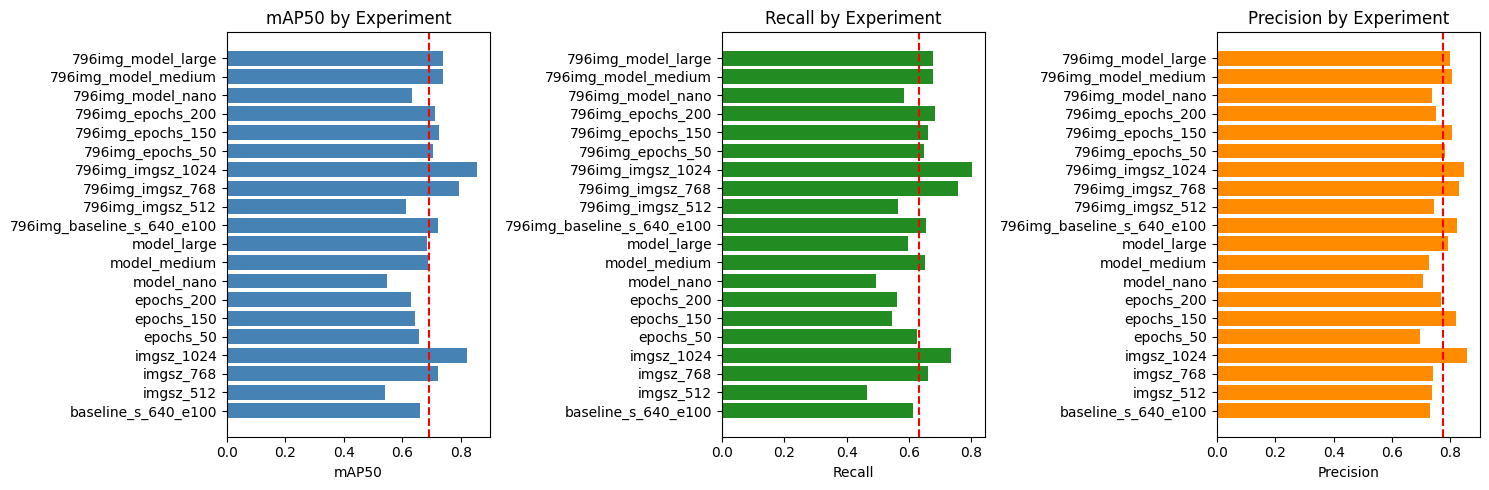

In [19]:
if MATPLOTLIB_AVAILABLE and successful_results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    exp_names = [r['experiment'] for r in successful_results]
    mAP50s = [r['mAP50'] for r in successful_results]
    recalls = [r['recall'] for r in successful_results]
    precisions = [r['precision'] for r in successful_results]
    
    # mAP50 comparison
    axes[0].barh(exp_names, mAP50s, color='steelblue')
    axes[0].set_xlabel('mAP50')
    axes[0].set_title('mAP50 by Experiment')
    axes[0].axvline(x=sum(mAP50s)/len(mAP50s), color='red', linestyle='--', label='Mean')
    
    # Recall comparison
    axes[1].barh(exp_names, recalls, color='forestgreen')
    axes[1].set_xlabel('Recall')
    axes[1].set_title('Recall by Experiment')
    axes[1].axvline(x=sum(recalls)/len(recalls), color='red', linestyle='--', label='Mean')
    
    # Precision comparison
    axes[2].barh(exp_names, precisions, color='darkorange')
    axes[2].set_xlabel('Precision')
    axes[2].set_title('Precision by Experiment')
    axes[2].axvline(x=sum(precisions)/len(precisions), color='red', linestyle='--', label='Mean')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = output_dir / 'experiment_comparison.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")
    
    plt.show()
else:
    print("Skipping plots (matplotlib not available or no successful experiments)")

Figure saved to: jupiter_inlet_experiments_v2/sahi_comparison.png


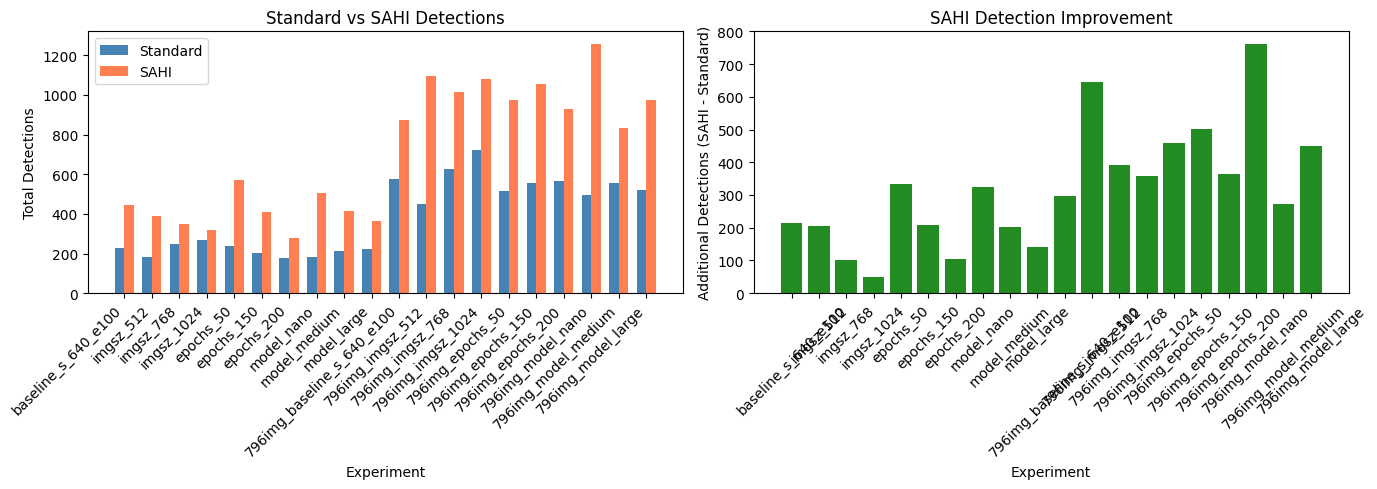

In [20]:
# SAHI comparison plot
if MATPLOTLIB_AVAILABLE and RUN_SAHI_EVALUATION:
    sahi_results_plot = [r for r in successful_results if r.get('sahi_detections') and r.get('std_detections')]
    
    if sahi_results_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        exp_names = [r['experiment'] for r in sahi_results_plot]
        std_dets = [r['std_detections'] for r in sahi_results_plot]
        sahi_dets = [r['sahi_detections'] for r in sahi_results_plot]
        increases = [r.get('detection_increase', 0) for r in sahi_results_plot]
        
        # Detection counts: Standard vs SAHI
        x = range(len(exp_names))
        width = 0.35
        
        axes[0].bar([i - width/2 for i in x], std_dets, width, label='Standard', color='steelblue')
        axes[0].bar([i + width/2 for i in x], sahi_dets, width, label='SAHI', color='coral')
        axes[0].set_xlabel('Experiment')
        axes[0].set_ylabel('Total Detections')
        axes[0].set_title('Standard vs SAHI Detections')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(exp_names, rotation=45, ha='right')
        axes[0].legend()
        
        # Detection increase
        colors = ['forestgreen' if inc >= 0 else 'red' for inc in increases]
        axes[1].bar(exp_names, increases, color=colors)
        axes[1].set_xlabel('Experiment')
        axes[1].set_ylabel('Additional Detections (SAHI - Standard)')
        axes[1].set_title('SAHI Detection Improvement')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        plt.tight_layout()
        
        # Save figure
        fig_path = output_dir / 'sahi_comparison.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {fig_path}")
        
        plt.show()

## 9. SAHI Metrics & Prediction Visualizations

In [21]:
# ── Backfill SAHI metrics for experiments already trained ──────────────
# If you ran experiments BEFORE sahi_mAP50 was added, this cell will
# compute and save the metrics retroactively from the saved best.pt files.

needs_backfill = [
    r for r in results_summary
    if r.get("status") == "success"
    and r.get("best_model_path")
    and r.get("sahi_mAP50") is None
]

print(f"Experiments needing SAHI metric backfill: {len(needs_backfill)}")
for r in needs_backfill:
    print(f"  - {r['experiment']}")

for r in needs_backfill:
    exp_name = r["experiment"]
    model_path = r["best_model_path"]
    imgsz = r["imgsz"]

    print(f"\nBackfilling: {exp_name}  (imgsz={imgsz})")

    if not Path(model_path).exists():
        print(f"  SKIP — model not found: {model_path}")
        continue

    sahi_m = evaluate_with_sahi_metrics(
        model_path     = model_path,
        val_images_dir = val_images_dir,
        val_labels_dir = val_labels_dir,
        slice_size     = imgsz,
        overlap_ratio  = SAHI_OVERLAP_RATIO,
        conf_thresh    = SAHI_CONFIDENCE_THRESHOLD,
        iou_thresh     = 0.5,
    )

    if sahi_m:
        r["sahi_precision"] = sahi_m["precision"]
        r["sahi_recall"]    = sahi_m["recall"]
        r["sahi_mAP50"]     = sahi_m["mAP50"]
        print(f"  Precision: {sahi_m['precision']:.4f}  "
              f"Recall: {sahi_m['recall']:.4f}  "
              f"mAP50: {sahi_m['mAP50']:.4f}")
    else:
        print(f"  FAILED — evaluate_with_sahi_metrics returned None")

# Persist updated results back to the progress JSON
if needs_backfill:
    save_progress(results_summary, progress_file)
    print(f"\nBackfill complete. Results saved to {progress_file}")
else:
    print("Nothing to backfill — all experiments already have SAHI metrics.")


Experiments needing SAHI metric backfill: 0
Nothing to backfill — all experiments already have SAHI metrics.


In [22]:
# ── SAHI metrics summary table ──────────────────────────────────────
sahi_metric_cols = ['experiment', 'imgsz', 'sahi_mAP50', 'sahi_precision',
                    'sahi_recall', 'sahi_detections', 'std_detections',
                    'detection_increase_pct']

if PANDAS_AVAILABLE and results_summary:
    df_all = pd.DataFrame(results_summary)
    available = [c for c in sahi_metric_cols if c in df_all.columns]
    df_sahi_metrics = df_all[available].copy()
    for col in ['sahi_mAP50', 'sahi_precision', 'sahi_recall']:
        if col in df_sahi_metrics.columns:
            df_sahi_metrics[col] = df_sahi_metrics[col].apply(
                lambda x: f"{x:.4f}" if pd.notna(x) and x is not None else "N/A")
    # Sort by sahi_mAP50 descending for easy reading
    if 'sahi_mAP50' in df_sahi_metrics.columns:
        df_sahi_metrics = df_sahi_metrics.sort_values('sahi_mAP50', ascending=False)
    print("SAHI Metrics Summary (sorted by mAP50)")
    print("=" * 100)
    print(df_sahi_metrics.to_string(index=False))
else:
    print("No results loaded — run the experiments or backfill cell first.")


SAHI Metrics Summary (sorted by mAP50)
                experiment  imgsz sahi_mAP50 sahi_precision sahi_recall  sahi_detections  std_detections  detection_increase_pct
                imgsz_1024   1024     0.7727         0.7514      0.8442              318             268                    18.7
         796img_imgsz_1024   1024     0.7540         0.4991      0.8766             1082             723                    49.7
          796img_imgsz_768    768     0.7063         0.5177      0.8539             1016             624                    62.8
                 imgsz_768    768     0.6549         0.6275      0.7792              349             247                    41.3
796img_baseline_s_640_e100    640     0.6489         0.5407      0.7662              873             576                    51.6
               model_large    640     0.6405         0.6397      0.7321              363             221                    64.3
       796img_model_medium    640     0.6321         0.572

Saved: jupiter_inlet_experiments_v2/sahi_metrics_comparison.png


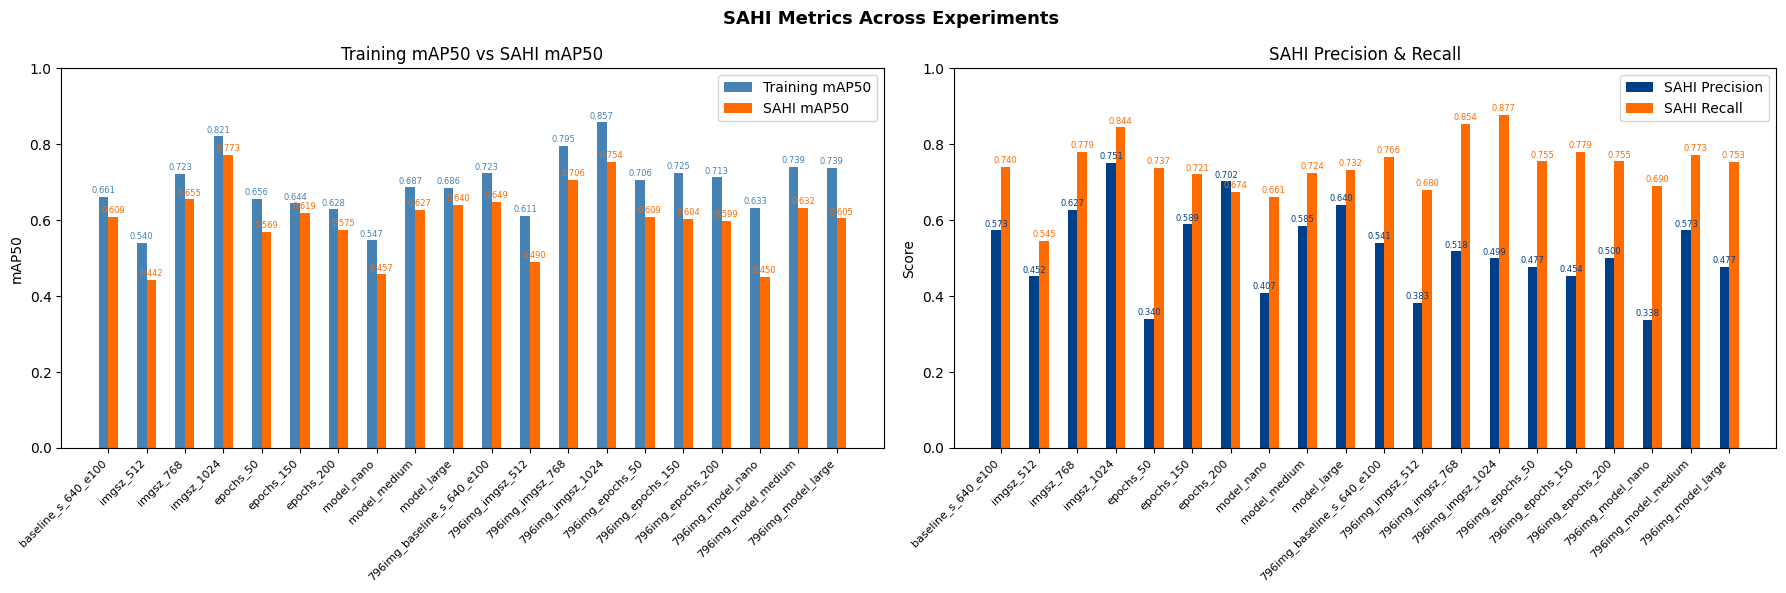

In [23]:
# ── SAHI mAP50 / Precision / Recall bar chart ───────────────────────
if MATPLOTLIB_AVAILABLE and results_summary:
    sahi_rows = [
        r for r in results_summary
        if r.get('status') == 'success'
        and r.get('sahi_mAP50') is not None
    ]
    if not sahi_rows:
        print("No SAHI metrics yet — run the backfill cell above first.")
    else:
        names  = [r['experiment'] for r in sahi_rows]
        s_map  = [r['sahi_mAP50']    for r in sahi_rows]
        s_prec = [r['sahi_precision'] for r in sahi_rows]
        s_rec  = [r['sahi_recall']    for r in sahi_rows]
        t_map  = [r.get('mAP50', 0)   for r in sahi_rows]

        x     = np.arange(len(names))
        width = 0.25

        fig, axes = plt.subplots(1, 2, figsize=(max(14, len(names)*0.9), 6))

        # Left: Training mAP50 vs SAHI mAP50
        axes[0].bar(x - width/2, t_map, width, label='Training mAP50', color='steelblue')
        axes[0].bar(x + width/2, s_map, width, label='SAHI mAP50',     color='#ff6b00')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        axes[0].set_ylabel('mAP50')
        axes[0].set_title('Training mAP50 vs SAHI mAP50')
        axes[0].set_ylim(0, 1.0)
        axes[0].legend()
        for xi, (tm, sm) in enumerate(zip(t_map, s_map)):
            axes[0].text(xi - width/2, tm + 0.01, f"{tm:.3f}", ha='center', fontsize=6, color='steelblue')
            axes[0].text(xi + width/2, sm + 0.01, f"{sm:.3f}", ha='center', fontsize=6, color='#ff6b00')

        # Right: SAHI Precision & Recall
        axes[1].bar(x - width/2, s_prec, width, label='SAHI Precision', color='#003f8a')
        axes[1].bar(x + width/2, s_rec,  width, label='SAHI Recall',    color='#ff6b00')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        axes[1].set_ylabel('Score')
        axes[1].set_title('SAHI Precision & Recall')
        axes[1].set_ylim(0, 1.0)
        axes[1].legend()
        for xi, (sp, sr) in enumerate(zip(s_prec, s_rec)):
            axes[1].text(xi - width/2, sp + 0.01, f"{sp:.3f}", ha='center', fontsize=6, color='#003f8a')
            axes[1].text(xi + width/2, sr + 0.01, f"{sr:.3f}", ha='center', fontsize=6, color='#ff6b00')

        plt.suptitle('SAHI Metrics Across Experiments', fontsize=13, fontweight='bold')
        plt.tight_layout()
        output_dir = Path(BASE_CONFIG['project'])
        output_dir.mkdir(exist_ok=True)
        plt.savefig(output_dir / 'sahi_metrics_comparison.png', dpi=150, bbox_inches='tight')
        print(f"Saved: {output_dir}/sahi_metrics_comparison.png")
        plt.show()


### Visualize GT vs SAHI Predictions

Dark-blue solid boxes = **ground truth**  
Orange dashed boxes = **SAHI predictions**

In [24]:
# ── Pick which model to visualise ───────────────────────────────────
# By default: the experiment with the best SAHI mAP50.
# Change BEST_MODEL_PATH to any best.pt you prefer.

successful = [r for r in results_summary
              if r.get('status') == 'success' and r.get('sahi_mAP50') is not None]

if successful:
    best_exp      = max(successful, key=lambda r: r['sahi_mAP50'])
    BEST_MODEL_PATH = best_exp['best_model_path']
    VIZ_SLICE_SIZE  = best_exp['imgsz']
    print(f"Visualising: {best_exp['experiment']}")
    print(f"  Model : {BEST_MODEL_PATH}")
    print(f"  Slice : {VIZ_SLICE_SIZE}px")
else:
    # Fallback — edit these manually if results_summary is not populated
    BEST_MODEL_PATH = "jupiter_inlet_experiments_v2/796img_baseline_s_640_e100/weights/best.pt"
    VIZ_SLICE_SIZE  = 640
    print("No results found — using fallback path. Edit BEST_MODEL_PATH if needed.")


Visualising: imgsz_1024
  Model : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_experiments/imgsz_10242/weights/best.pt
  Slice : 1024px


   Figure saved to jupiter_inlet_experiments_v2/sahi_gt_vs_pred.png


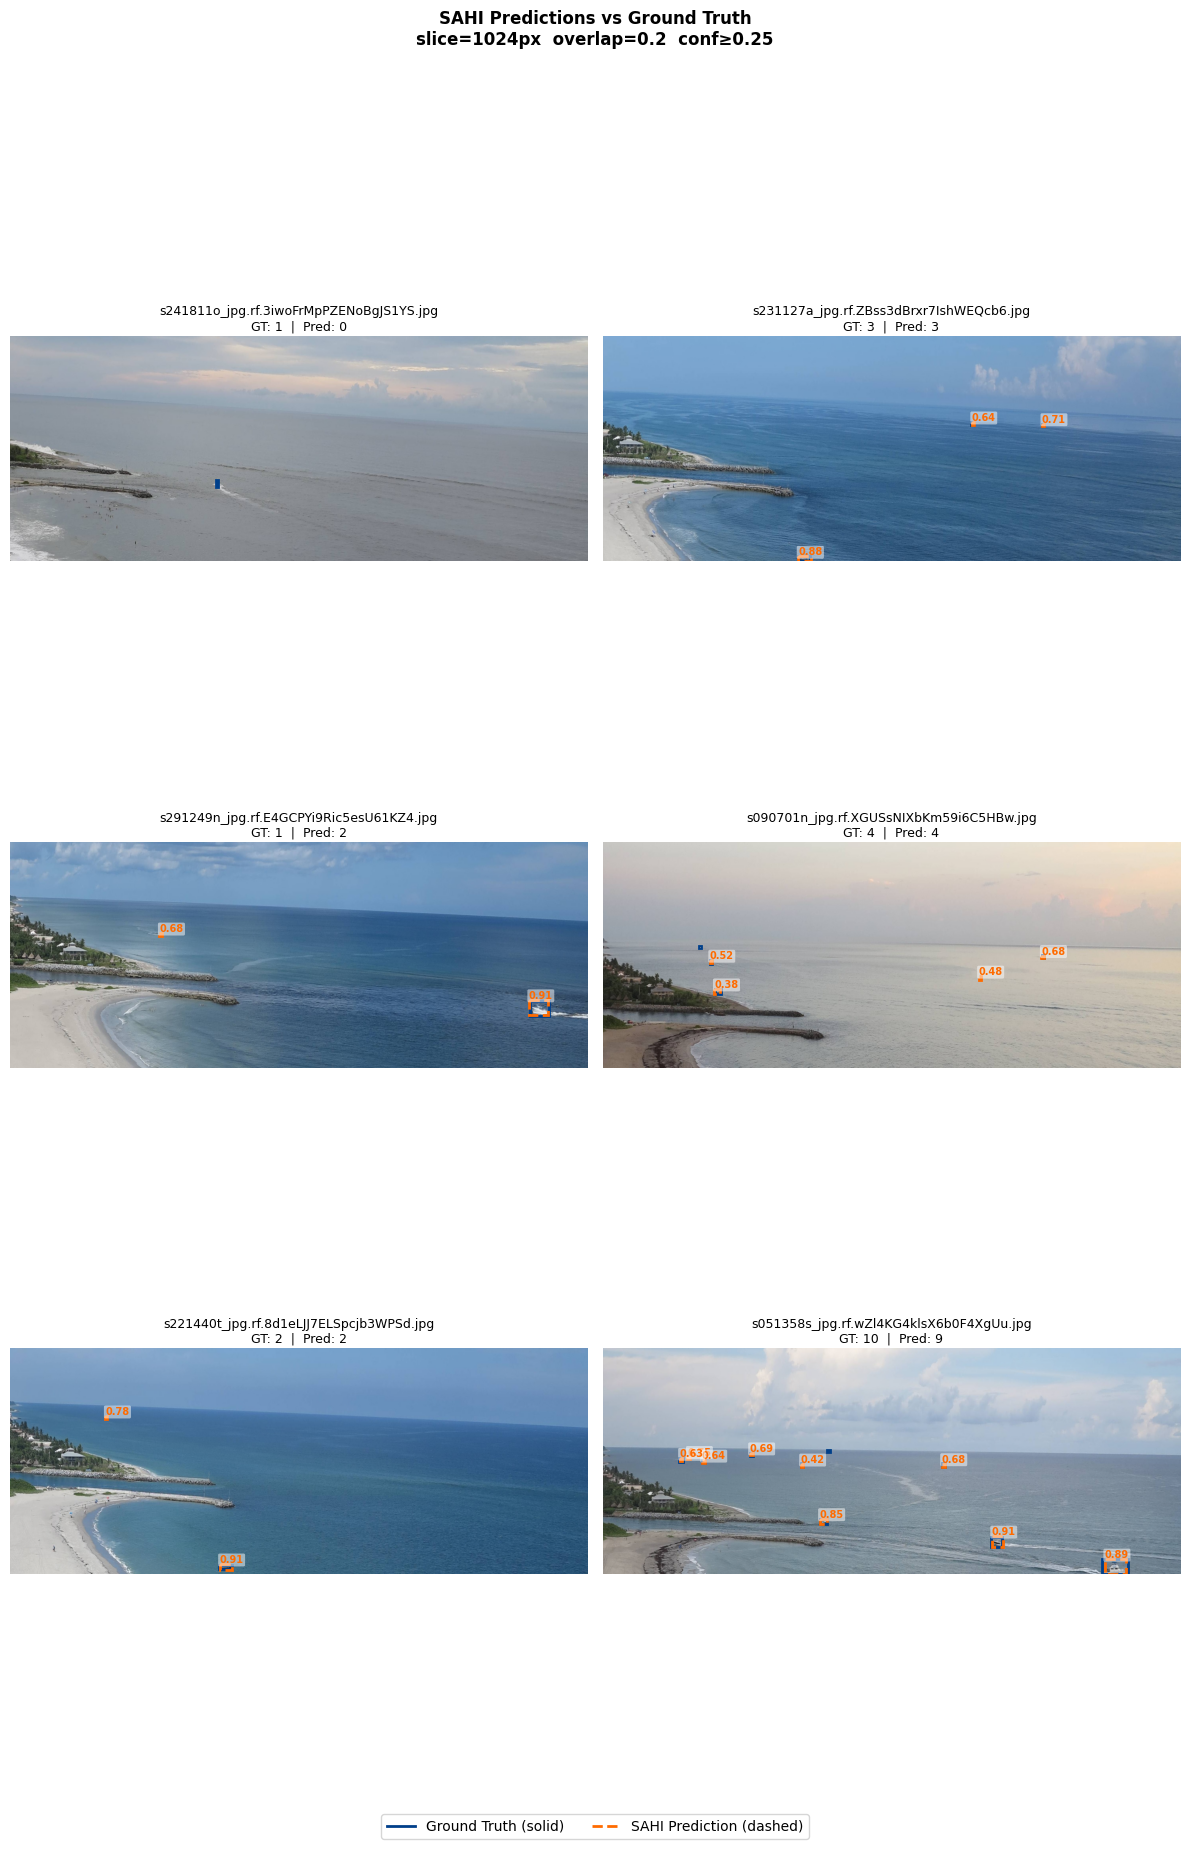

   Memory cleared.


In [25]:
# ── Generate visualizations ──────────────────────────────────────────
output_dir = Path(BASE_CONFIG['project'])
output_dir.mkdir(exist_ok=True)

visualize_sahi_predictions(
    model_path     = BEST_MODEL_PATH,
    val_images_dir = val_images_dir,
    val_labels_dir = val_labels_dir,
    slice_size     = VIZ_SLICE_SIZE,
    overlap_ratio  = SAHI_OVERLAP_RATIO,
    conf_thresh    = SAHI_CONFIDENCE_THRESHOLD,
    n_images       = 6,      # how many val images to show
    seed           = 42,     # change for different random selection
    save_path      = str(output_dir / "sahi_gt_vs_pred.png"),
)


## 10. IoU Threshold Sweep (0.3 → 0.6)

Tests how the IoU matching threshold affects SAHI Precision, Recall, and mAP50.
A lower IoU is more lenient (more TPs, higher recall), higher IoU is stricter (fewer TPs, higher precision).

In [26]:
# ── Configuration ────────────────────────────────────────────────────
# Uses your best model by sahi_mAP50. Override SWEEP_MODEL_PATH if needed.

successful = [r for r in results_summary
              if r.get("status") == "success" and r.get("sahi_mAP50") is not None]

if successful:
    best_exp        = max(successful, key=lambda r: r["sahi_mAP50"])
    SWEEP_MODEL_PATH  = best_exp["best_model_path"]
    SWEEP_SLICE_SIZE  = best_exp["imgsz"]
    SWEEP_EXP_NAME    = best_exp["experiment"]
    print(f"Running sweep on: {SWEEP_EXP_NAME}")
    print(f"  Model : {SWEEP_MODEL_PATH}")
    print(f"  Slice : {SWEEP_SLICE_SIZE}px")
else:
    # Fallback — edit manually
    SWEEP_MODEL_PATH  = "jupiter_inlet_experiments_v2/796img_imgsz_768/weights/best.pt"
    SWEEP_SLICE_SIZE  = 768
    SWEEP_EXP_NAME    = "796img_imgsz_768"
    print("No results found — using fallback. Edit SWEEP_MODEL_PATH if needed.")

IOU_THRESHOLDS   = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
SWEEP_CONF       = SAHI_CONFIDENCE_THRESHOLD   # keep conf fixed
SWEEP_OVERLAP    = SAHI_OVERLAP_RATIO           # keep overlap fixed

print(f"\nIoU thresholds to test: {IOU_THRESHOLDS}")
print(f"Conf threshold (fixed): {SWEEP_CONF}")
print(f"Overlap ratio  (fixed): {SWEEP_OVERLAP}")


Running sweep on: imgsz_1024
  Model : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_experiments/imgsz_10242/weights/best.pt
  Slice : 1024px

IoU thresholds to test: [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
Conf threshold (fixed): 0.25
Overlap ratio  (fixed): 0.2


In [27]:
# ── Run the sweep ─────────────────────────────────────────────────────
iou_sweep_results = []

header = f"  {'IoU':>6}  {'Precision':>10}  {'Recall':>8}  {'mAP50':>8}  {'Detections':>12}"
print(f"Starting IoU sweep — {len(IOU_THRESHOLDS)} runs\n")
print(header)
print("  " + "-" * 52)

for iou_thresh in IOU_THRESHOLDS:
    m = evaluate_with_sahi_metrics(
        model_path     = SWEEP_MODEL_PATH,
        val_images_dir = val_images_dir,
        val_labels_dir = val_labels_dir,
        slice_size     = SWEEP_SLICE_SIZE,
        overlap_ratio  = SWEEP_OVERLAP,
        conf_thresh    = SWEEP_CONF,
        iou_thresh     = iou_thresh,
    )
    if m:
        row = {
            "iou_thresh":   iou_thresh,
            "precision":    m["precision"],
            "recall":       m["recall"],
            "mAP50":        m["mAP50"],
            "detections":   m["total_detections"],
            "time_per_img": m["time_per_image"],
        }
        iou_sweep_results.append(row)
        print(f"  {iou_thresh:>6.2f}  {m['precision']:>10.4f}  "
              f"{m['recall']:>8.4f}  {m['mAP50']:>8.4f}  "
              f"{m['total_detections']:>12}")
    else:
        print(f"  {iou_thresh:>6.2f}  FAILED")

print("\nSweep complete.")


Starting IoU sweep — 7 runs

     IoU   Precision    Recall     mAP50    Detections
  ----------------------------------------------------
   Memory cleared.
    0.30      0.8150    0.9156    0.8711           692
   Memory cleared.
    0.35      0.8064    0.9058    0.8663           692
   Memory cleared.
    0.40      0.7962    0.8945    0.7881           692
   Memory cleared.
    0.45      0.7818    0.8782    0.7830           692
   Memory cleared.
    0.50      0.7514    0.8442    0.7727           692
   Memory cleared.
    0.55      0.7182    0.8068    0.7555           692
   Memory cleared.
    0.60      0.6633    0.7451    0.6644           692

Sweep complete.


In [28]:
# ── Results table ─────────────────────────────────────────────────────
if PANDAS_AVAILABLE and iou_sweep_results:
    df_iou = pd.DataFrame(iou_sweep_results)
    # Highlight the best row for each metric
    best_map_idx  = df_iou["mAP50"].idxmax()
    best_prec_idx = df_iou["precision"].idxmax()
    best_rec_idx  = df_iou["recall"].idxmax()

    print(f"\nIoU Sweep Results — {SWEEP_EXP_NAME}")
    print("=" * 65)
    print(df_iou.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("=" * 65)
    print(f"  Best mAP50     → IoU = {df_iou.loc[best_map_idx,  'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_map_idx,  'mAP50']:.4f})")
    print(f"  Best Precision → IoU = {df_iou.loc[best_prec_idx, 'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_prec_idx, 'precision']:.4f})")
    print(f"  Best Recall    → IoU = {df_iou.loc[best_rec_idx,  'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_rec_idx,  'recall']:.4f})")
else:
    print("No sweep results to display.")



IoU Sweep Results — imgsz_1024
 iou_thresh  precision  recall  mAP50  detections  time_per_img
     0.3000     0.8150  0.9156 0.8711         692        0.1340
     0.3500     0.8064  0.9058 0.8663         692        0.1310
     0.4000     0.7962  0.8945 0.7881         692        0.1310
     0.4500     0.7818  0.8782 0.7830         692        0.1320
     0.5000     0.7514  0.8442 0.7727         692        0.1330
     0.5500     0.7182  0.8068 0.7555         692        0.1340
     0.6000     0.6633  0.7451 0.6644         692        0.1330
  Best mAP50     → IoU = 0.30  (0.8711)
  Best Precision → IoU = 0.30  (0.8150)
  Best Recall    → IoU = 0.30  (0.9156)


Saved: jupiter_inlet_experiments_v2/iou_sweep.png


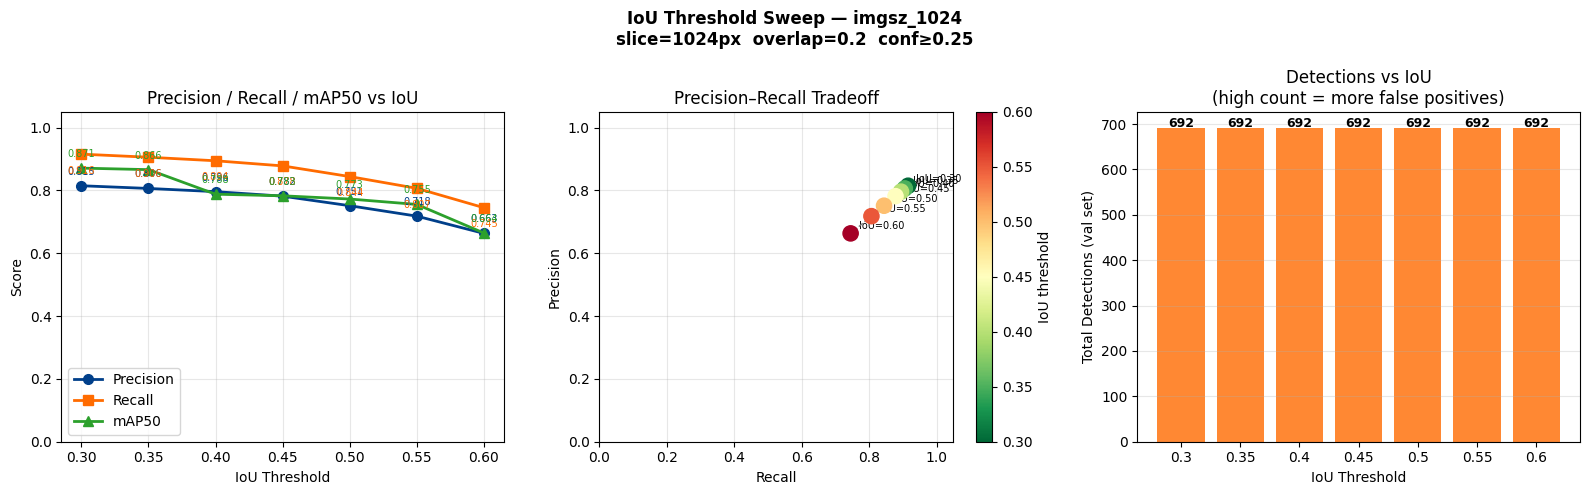

In [29]:
# ── Plot sweep results ────────────────────────────────────────────────
if MATPLOTLIB_AVAILABLE and iou_sweep_results:
    df_iou = pd.DataFrame(iou_sweep_results) if PANDAS_AVAILABLE \
             else None
    ious   = [r["iou_thresh"]  for r in iou_sweep_results]
    precs  = [r["precision"]   for r in iou_sweep_results]
    recs   = [r["recall"]      for r in iou_sweep_results]
    maps   = [r["mAP50"]       for r in iou_sweep_results]
    dets   = [r["detections"]  for r in iou_sweep_results]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Left: Precision / Recall / mAP50 vs IoU ──────────────────────
    axes[0].plot(ious, precs, "o-", color="#003f8a", linewidth=2,
                 markersize=7, label="Precision")
    axes[0].plot(ious, recs,  "s-", color="#ff6b00", linewidth=2,
                 markersize=7, label="Recall")
    axes[0].plot(ious, maps,  "^-", color="#2ca02c", linewidth=2,
                 markersize=7, label="mAP50")
    # annotate each point
    for iou, p, r, m in zip(ious, precs, recs, maps):
        axes[0].annotate(f"{p:.3f}", (iou, p), textcoords="offset points",
                         xytext=(0, 8),  fontsize=7, color="#003f8a", ha="center")
        axes[0].annotate(f"{r:.3f}", (iou, r), textcoords="offset points",
                         xytext=(0, -14), fontsize=7, color="#ff6b00", ha="center")
        axes[0].annotate(f"{m:.3f}", (iou, m), textcoords="offset points",
                         xytext=(0, 8),  fontsize=7, color="#2ca02c", ha="center")
    axes[0].set_xlabel("IoU Threshold")
    axes[0].set_ylabel("Score")
    axes[0].set_title("Precision / Recall / mAP50 vs IoU")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xticks(ious)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Middle: Precision–Recall tradeoff curve ───────────────────────
    sc = axes[1].scatter(recs, precs, c=ious, cmap="RdYlGn_r",
                         s=120, zorder=5)
    axes[1].plot(recs, precs, "--", color="grey", linewidth=1, zorder=4)
    for iou, p, r in zip(ious, precs, recs):
        axes[1].annotate(f"IoU={iou:.2f}", (r, p),
                         textcoords="offset points", xytext=(6, 3), fontsize=7)
    plt.colorbar(sc, ax=axes[1], label="IoU threshold")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision–Recall Tradeoff")
    axes[1].set_xlim(0, 1.05)
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.3)

    # ── Right: Total detections vs IoU (shows false-positive trend) ──
    axes[2].bar([str(i) for i in ious], dets, color="#ff6b00", alpha=0.8)
    for xi, (iou, d) in enumerate(zip(ious, dets)):
        axes[2].text(xi, d + 2, str(d), ha="center", fontsize=9, fontweight="bold")
    axes[2].set_xlabel("IoU Threshold")
    axes[2].set_ylabel("Total Detections (val set)")
    axes[2].set_title("Detections vs IoU\n(high count = more false positives)")
    axes[2].grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        f'IoU Threshold Sweep — {SWEEP_EXP_NAME}\n'
        f'slice={SWEEP_SLICE_SIZE}px  overlap={SWEEP_OVERLAP}  conf≥{SWEEP_CONF}',
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    output_dir = Path(BASE_CONFIG["project"])
    output_dir.mkdir(exist_ok=True)
    plt.savefig(output_dir / "iou_sweep.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {output_dir}/iou_sweep.png")
    plt.show()


Best IoU threshold: 0.30
  Precision: 0.8150
  Recall:    0.9156
  mAP50:     0.8711

Generating sample visualizations at IoU=0.30...
   Figure saved to jupiter_inlet_experiments_v2/sahi_best_iou_0.30.png


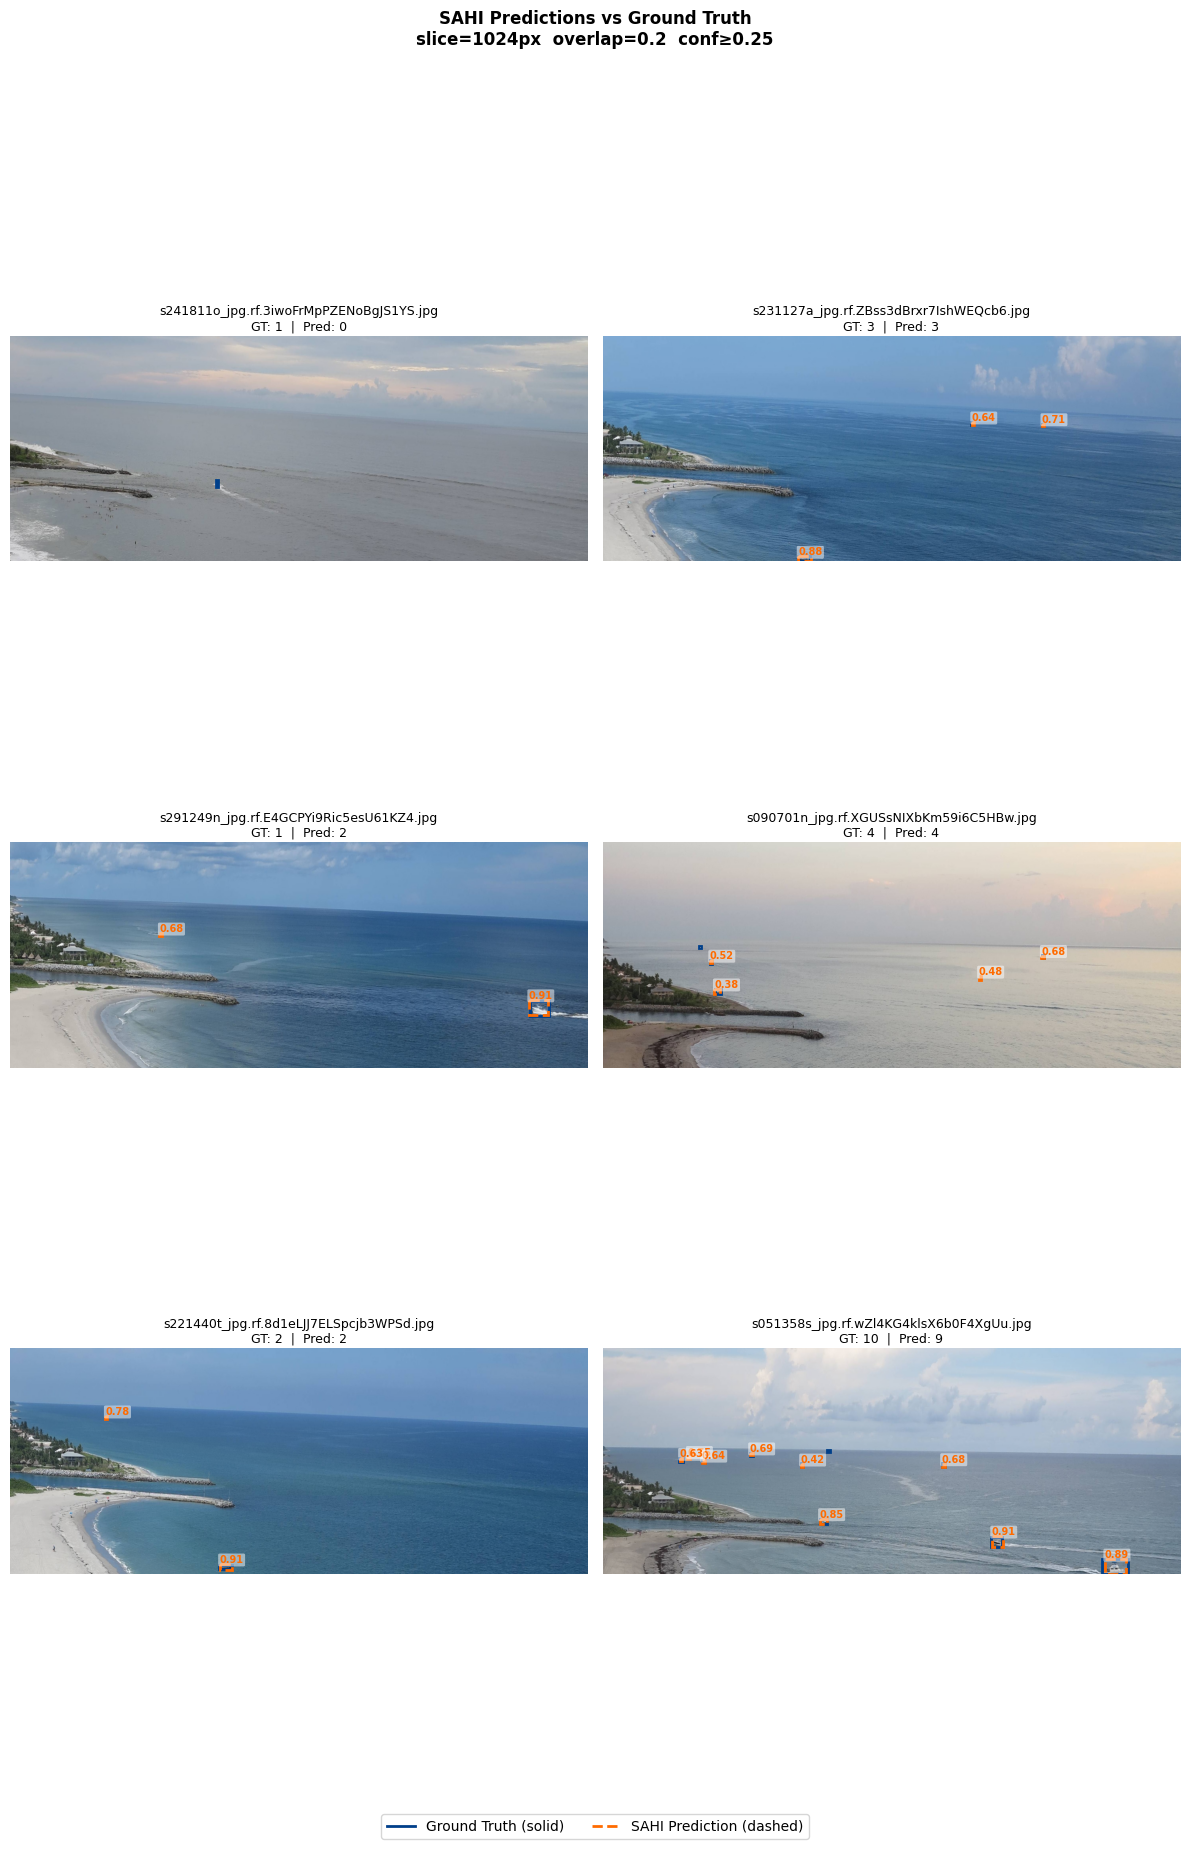

   Memory cleared.


In [30]:
# ── Visualize best IoU on sample images ──────────────────────────────
# Re-runs visualization with the IoU that gave the best mAP50
if iou_sweep_results:
    best_row    = max(iou_sweep_results, key=lambda r: r["mAP50"])
    best_iou    = best_row["iou_thresh"]
    print(f"Best IoU threshold: {best_iou:.2f}")
    print(f"  Precision: {best_row['precision']:.4f}")
    print(f"  Recall:    {best_row['recall']:.4f}")
    print(f"  mAP50:     {best_row['mAP50']:.4f}")
    print(f"\nGenerating sample visualizations at IoU={best_iou:.2f}...")

    output_dir = Path(BASE_CONFIG["project"])
    visualize_sahi_predictions(
        model_path     = SWEEP_MODEL_PATH,
        val_images_dir = val_images_dir,
        val_labels_dir = val_labels_dir,
        slice_size     = SWEEP_SLICE_SIZE,
        overlap_ratio  = SWEEP_OVERLAP,
        conf_thresh    = SWEEP_CONF,
        n_images       = 6,
        seed           = 42,
        save_path      = str(output_dir / f"sahi_best_iou_{best_iou:.2f}.png"),
    )
else:
    print("Run the sweep cells above first.")
